# EDA — Logic_Based_Educational_Queries **(FLAT + reasoning)**

Nguon: `data/raw/Logic_Based_Educational_Queries_clean_reasoning.json` — schema **flat** 
(1 dong / cau, underscore keys), da co `premises_used` (0-based) + `reasoning{type,steps}`.

Khac voi `eda_and_preprocessing.ipynb` (schema raw long nhau). File nay KHONG sua data, chi EDA.


In [41]:
# === Setup + load file reasoning FLAT ===
import json, re, sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- tim PROJECT_ROOT (chua data/raw) ---
def _find_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "data" / "raw").is_dir():
            return p
    raise RuntimeError("Khong thay project root (data/raw)")

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

SRC = PROJECT_ROOT / "data" / "raw" / "clean_v3_reasoning" / "Logic_Based_Educational_Queries_clean_reasoning.json"
if not SRC.is_file():
    SRC = PROJECT_ROOT / "data" / "processed" / "lbeq_with_reasoning.json"
FIG_DIR = PROJECT_ROOT / "notebooks" / "figs_flat"
FIG_DIR.mkdir(parents=True, exist_ok=True)

rows = json.loads(SRC.read_text(encoding="utf-8"))
print(f"Nguon: {SRC}")
print(f"So dong (cau): {len(rows)}  |  keys: {sorted(rows[0].keys())}")

df = pd.DataFrame(rows)
# Chuan hoa key: nguon co the dung hyphen (BTC: premises-NL/premises-FOL) hoac underscore -> underscore
_renames = {"premises-NL": "premises_nl", "premises-FOL": "premises_fol", "question": "query"}
df = df.rename(columns={k: v for k, v in _renames.items() if k in df.columns and v not in df.columns})
print(f"So record (record_id distinct): {df['record_id'].nunique()}")
df.head(3)


Nguon: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\raw\clean_v3_reasoning\Logic_Based_Educational_Queries_clean_reasoning.json
So dong (cau): 776  |  keys: ['answer', 'explanation', 'premises-FOL', 'premises-NL', 'premises_used', 'q_idx', 'query', 'reasoning', 'record_id']
So record (record_id distinct): 410


,record_id,q_idx,premises_nl,premises_fol,query,answer,premises_used,explanation,reasoning
0,0,0,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x...",Which conclusion follows with the fewest premi...,A,[0],Premise 0 states that if a Python project is w...,"{'type': 'fol', 'steps': ['Rule: ∀x (WT(x) → O..."
1,0,1,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x...",Does it follow that if all Python projects are...,Yes,"[6, 9]",Premise 9 confirms all Python projects are wel...,"{'type': 'fol', 'steps': ['Fact: ∀x (WS(x))', ..."
2,1,0,[Students who have completed the core curricul...,"[ForAll(x, (completed_core_curriculum(x) ∧ pas...","Based on the above premises, which is the stro...",A,"[0, 1, 3, 4, 6, 7, 8, 9, 10]",Premises 6 and 7 confirm Sophia completed the ...,"{'type': 'fol', 'steps': ['Rule: ForAll(x, (co..."


In [42]:
# === In 5 sample (day du: premises NL/FOL [* = duoc dung], query, answer, premises_used, explanation, reasoning) ===
def show_sample(r, i):
    print("=" * 80)
    print(f"SAMPLE {i}  |  record_id={r['record_id']}  q_idx={r['q_idx']}  "
          f"answer={r['answer']!r}  premises_used={r.get('premises_used')}")
    print("=" * 80)
    nl = list(r.get("premises_nl") or [])
    fol = list(r.get("premises_fol") or [])
    pu = set(r.get("premises_used") or [])
    print("PREMISES  ([idx] NL  /  FOL ;  * = duoc dung trong premises_used)")
    for j in range(max(len(nl), len(fol))):
        mark = "*" if j in pu else " "
        print(f" {mark}[{j}] {nl[j] if j < len(nl) else ''}")
        print(f"       FOL: {fol[j] if j < len(fol) else ''}")
    print("\nQUERY:\n  " + str(r["query"]).replace("\n", "\n  "))
    print(f"\nEXPLANATION:\n  {r.get('explanation', '')}")
    rs = r.get("reasoning")
    print("\nREASONING (steps):")
    if rs and rs.get("steps"):
        for s in rs["steps"]:
            print(f"   - {s}")
    else:
        print("   (none)")
    print()

# 5 sample dau. Doi sang .sample(5, random_state=0) neu muon ngau nhien.
for _i, (_, _r) in enumerate(df.head(5).iterrows()):
    show_sample(_r, _i)


SAMPLE 0  |  record_id=0  q_idx=0  answer='A'  premises_used=[0]
PREMISES  ([idx] NL  /  FOL ;  * = duoc dung trong premises_used)
 *[0] If a Python code is well-tested, then the project is optimized.
       FOL: ∀x (WT(x) → O(x))
  [1] If a Python code does not follow PEP 8 standards, then it is not well-tested.
       FOL: ∀x (¬PEP8(x) → ¬WT(x))
  [2] All Python projects are easy to maintain.
       FOL: ∀x (EM(x))
  [3] All Python code is well-tested.
       FOL: ∀x (WT(x))
  [4] If a Python code follows PEP 8 standards, then it is easy to maintain.
       FOL: ∀x (PEP8(x) → EM(x))
  [5] If a Python code is well-tested, then it follows PEP 8 standards.
       FOL: ∀x (WT(x) → PEP8(x))
  [6] If a Python project is well-structured, then it is optimized.
       FOL: ∀x (WS(x) → O(x))
  [7] If a Python project is easy to maintain, then it is well-tested.
       FOL: ∀x (EM(x) → WT(x))
  [8] If a Python project is optimized, then it has clean and readable code.
       FOL: ∀x (O(x) → CR(

## 1. Phai sinh cot + phan loai cau

In [43]:
# === Derive cot phuc vu EDA ===
MCQ_RE = re.compile(r"\nA[\.\)]")  # option "A." hoac "A)" tren dong moi => MCQ

df["n_premises_nl"]   = df["premises_nl"].apply(lambda x: len(x or []))
df["n_premises_fol"]  = df["premises_fol"].apply(lambda x: len(x or []))
df["n_premises_used"] = df["premises_used"].apply(lambda x: len(x or []))
df["has_fol"]         = df["n_premises_fol"] > 0
df["use_ratio"]       = df.apply(lambda r: r["n_premises_used"]/r["n_premises_nl"] if r["n_premises_nl"] else np.nan, axis=1)

df["answer_norm"] = df["answer"].astype(str).str.strip()
df["is_mcq"] = df["query"].astype(str).apply(lambda q: bool(MCQ_RE.search(q)))
df["is_yn"]  = (~df["is_mcq"]) & df["answer_norm"].isin(["Yes", "No"])
df["is_open"] = (~df["is_mcq"]) & (~df["is_yn"])
df["q_type"] = np.where(df["is_mcq"], "MCQ", np.where(df["is_yn"], "Yes/No", "Open/Other"))

# reasoning
df["has_reasoning"] = df["reasoning"].apply(lambda r: bool(r))
df["n_steps"] = df["reasoning"].apply(lambda r: len(r["steps"]) if r else 0)
df["reasoning_type"] = df["reasoning"].apply(lambda r: r.get("type") if r else None)

print("Tong cau:", len(df))
print("Co reasoning:", int(df["has_reasoning"].sum()), f"({df['has_reasoning'].mean():.1%})")
print("Loai cau:", dict(df["q_type"].value_counts()))
print("FOL coverage:", f"{df['has_fol'].mean():.1%}")


Tong cau: 776
Co reasoning: 776 (100.0%)
Loai cau: {'Yes/No': 414, 'MCQ': 336, 'Open/Other': 26}
FOL coverage: 100.0%


## 2. Phan phoi premise (NL / FOL / used)

premise NL / cau : mean=10.85  P50=10  P90=19  P99=29  max=36
premise FOL / cau: mean=10.94  P50=10  P90=19  P99=29  max=36
premise USED/ cau: mean=2.66  P50=2  P90=4  P99=9  max=20
use_ratio        : mean=0.32  P50=0  P90=1  P99=1  max=1
NL != FOL count (co FOL): 21


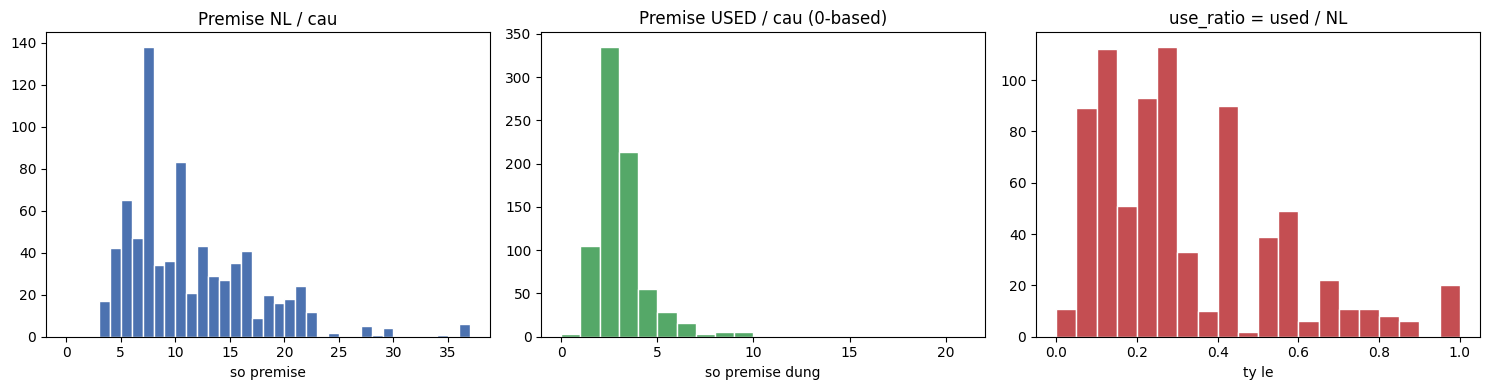

In [44]:
# === Premise distributions ===
def _stat(s, name):
    s = s.dropna()
    print(f"{name}: mean={s.mean():.2f}  P50={s.median():.0f}  P90={s.quantile(.9):.0f}  P99={s.quantile(.99):.0f}  max={s.max():.0f}")

_stat(df["n_premises_nl"],   "premise NL / cau ")
_stat(df["n_premises_fol"],  "premise FOL / cau")
_stat(df["n_premises_used"], "premise USED/ cau")
_stat(df["use_ratio"],       "use_ratio        ")
print("NL != FOL count (co FOL):", int(((df["n_premises_nl"] != df["n_premises_fol"]) & df["has_fol"]).sum()))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df["n_premises_nl"], bins=range(0, int(df["n_premises_nl"].max())+2), color="#4C72B0", edgecolor="white")
ax[0].set_title("Premise NL / cau"); ax[0].set_xlabel("so premise")
ax[1].hist(df["n_premises_used"], bins=range(0, int(df["n_premises_used"].max())+2), color="#55A868", edgecolor="white")
ax[1].set_title("Premise USED / cau (0-based)"); ax[1].set_xlabel("so premise dung")
ax[2].hist(df["use_ratio"].dropna(), bins=20, color="#C44E52", edgecolor="white")
ax[2].set_title("use_ratio = used / NL"); ax[2].set_xlabel("ty le")
plt.tight_layout(); plt.savefig(FIG_DIR / "F_premise_dist.png", dpi=120); plt.show()


## 3. Phan phoi nhan & loai cau

Answer (toan bo): {'Yes': 379, 'A': 187, 'B': 67, 'C': 56, 'No': 35, 'D': 26, 'Unknown': 26}
% Unknown: 3.4%

[MCQ] n=336  answer dist={'A': 187, 'B': 67, 'C': 56, 'D': 26}
[Yes/No] n=414  answer dist={'Yes': 379, 'No': 35}
[Open/Other] n=26  answer dist={'Unknown': 26}


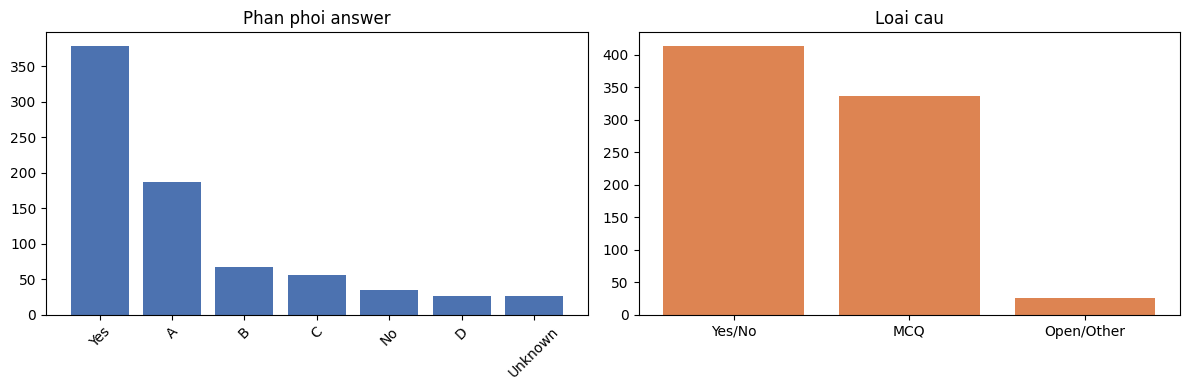

In [45]:
# === Answer label + question type ===
print("Answer (toan bo):", dict(df["answer_norm"].value_counts()))
print("% Unknown:", f"{(df['answer_norm']=='Unknown').mean():.1%}")
print()
for t in ("MCQ", "Yes/No", "Open/Other"):
    sub = df[df["q_type"] == t]
    print(f"[{t}] n={len(sub)}  answer dist={dict(sub['answer_norm'].value_counts().head(8))}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
vc = df["answer_norm"].value_counts()
ax[0].bar(vc.index.astype(str), vc.values, color="#4C72B0"); ax[0].set_title("Phan phoi answer")
ax[0].tick_params(axis="x", rotation=45)
tc = df["q_type"].value_counts()
ax[1].bar(tc.index, tc.values, color="#DD8452"); ax[1].set_title("Loai cau")
plt.tight_layout(); plt.savefig(FIG_DIR / "F_answer_qtype.png", dpi=120); plt.show()


## 4. Reasoning steps — EDA chuyen biet

Tong step: 4185  | tren 776 cau co reasoning
Step/cau: mean=5.4  P50=5  P90=7  max=24
Prefix breakdown: {'Rule': 1302, 'Derive': 1344, 'Conclusion': 776, 'Fact': 763}
Cau co dung 1 Conclusion: 776/776  | !=1: 0
Step lo cite 'premise N' (mong doi 0): 0
reasoning.type: {'fol': 776}


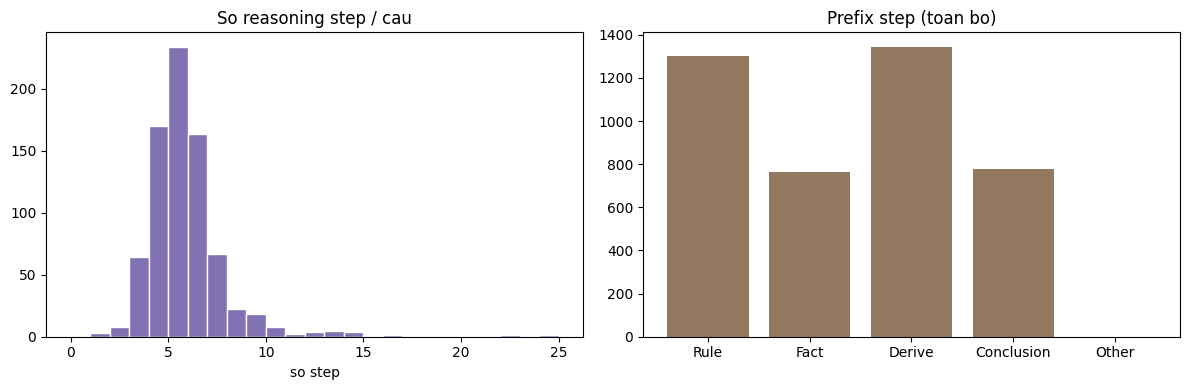

In [46]:
# === Reasoning: so step, loai prefix, do dai ===
PREFIXES = ("Rule", "Fact", "Derive", "Conclusion")
def step_prefix(s: str) -> str:
    for p in PREFIXES:
        if s.startswith(p + ":"):
            return p
    return "Other"

with_r = df[df["has_reasoning"]]
all_steps = [s for r in with_r["reasoning"] for s in r["steps"]]
prefix_cnt = Counter(step_prefix(s) for s in all_steps)
# moi cau co dung 1 Conclusion?
n_concl = with_r["reasoning"].apply(lambda r: sum(1 for s in r["steps"] if s.startswith("Conclusion:")))
# co step lo cite "premise N" khong (mong doi 0 sau khi neutralize)
n_numbered = sum(1 for s in all_steps if re.search(r"(?i)\bpremise\s+\d", s))

print(f"Tong step: {len(all_steps)}  | tren {len(with_r)} cau co reasoning")
print(f"Step/cau: mean={with_r['n_steps'].mean():.1f}  P50={with_r['n_steps'].median():.0f}  P90={with_r['n_steps'].quantile(.9):.0f}  max={with_r['n_steps'].max():.0f}")
print(f"Prefix breakdown: {dict(prefix_cnt)}")
print(f"Cau co dung 1 Conclusion: {int((n_concl==1).sum())}/{len(with_r)}  | !=1: {int((n_concl!=1).sum())}")
print(f"Step lo cite 'premise N' (mong doi 0): {n_numbered}")
print(f"reasoning.type: {dict(with_r['reasoning_type'].value_counts())}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(with_r["n_steps"], bins=range(0, int(with_r["n_steps"].max())+2), color="#8172B3", edgecolor="white")
ax[0].set_title("So reasoning step / cau"); ax[0].set_xlabel("so step")
pf = pd.Series(prefix_cnt).reindex(list(PREFIXES)+["Other"]).fillna(0)
ax[1].bar(pf.index, pf.values, color="#937860"); ax[1].set_title("Prefix step (toan bo)")
plt.tight_layout(); plt.savefig(FIG_DIR / "F_reasoning_steps.png", dpi=120); plt.show()


## 5. Explanation cite ⊆ premises_used? (kiem tra 0-based)

In [47]:
# === Explanation citation: "Premise N" co nam trong premises_used (0-based) khong ===
CITE = re.compile(r"[Pp]remises?\s+(\d+(?:\s*(?:,\s*and\s*|,\s*|\s+and\s+|\s*&\s*)\d+)*)")
def cited_nums(e):
    return [int(x) for g in CITE.findall(str(e)) for x in re.findall(r"\d+", g)]

sub_ok = within = total_cite = 0
rows_with_cite = 0
for _, r in df.iterrows():
    nums = cited_nums(r["explanation"])
    if not nums:
        continue
    rows_with_cite += 1
    pu = set(r["premises_used"] or [])
    for n in nums:
        total_cite += 1
        if n in pu:
            within += 1
    if set(nums) <= pu:
        sub_ok += 1

print(f"Cau co cite premise trong explanation: {rows_with_cite}/{len(df)}")
print(f"So cite nam trong premises_used (0-based): {within}/{total_cite} = {within/total_cite:.1%}")
print(f"Cau co TOAN BO cite ⊆ premises_used: {sub_ok}/{rows_with_cite} = {sub_ok/max(rows_with_cite,1):.1%}")
print("(Luu y: explanation thuong cite ca premise cua dap an SAI -> subset < 100% la binh thuong)")


Cau co cite premise trong explanation: 728/776
So cite nam trong premises_used (0-based): 2546/2688 = 94.7%
Cau co TOAN BO cite ⊆ premises_used: 638/728 = 87.6%
(Luu y: explanation thuong cite ca premise cua dap an SAI -> subset < 100% la binh thuong)


## 6. Export train/dev/test **CSV** (ghi de `data/processed/*.csv`)

Tu file reasoning flat -> 3 CSV, **reuse `split_record_ids.json`** (cung split, khong leak).
Cot list/dict (`premises_nl`, `premises_fol`, `premises_used`, `reasoning`) ghi duoi dang **JSON string**.
Luong train QA (`prepare_data.py`) doc THANG 3 CSV nay.

In [48]:
# === Export 3 CSV: ghi de data/processed/{train,dev,test}.csv (luong train doc cai nay) ===
import json as _json

OUT = PROJECT_ROOT / "data" / "processed"
split_ids = _json.loads((OUT / "split_record_ids.json").read_text(encoding="utf-8"))
rid2split = {int(r): sp for sp, ids in split_ids.items() for r in ids}

_ex = df.copy()
_ex["split"] = _ex["record_id"].map(rid2split)
_ex["question"] = _ex["query"]
_ex["n_premises_used"] = _ex["premises_used"].apply(lambda x: len(x or []))
for c in ("premises_nl", "premises_fol", "premises_used", "reasoning"):
    _ex[c] = _ex[c].apply(lambda v: _json.dumps(v, ensure_ascii=False))

COLS = ["record_id", "q_idx", "n_premises_used", "question", "answer",
        "explanation", "premises_nl", "premises_fol", "premises_used", "reasoning"]

n_orphan = int(_ex["split"].isna().sum())
for sp in ("train", "dev", "test"):
    sub = _ex[_ex["split"] == sp][COLS]
    path = OUT / f"{sp}.csv"
    sub.to_csv(path, index=False, encoding="utf-8")
    n_reason = sub["reasoning"].apply(lambda s: s not in ("null", "")).sum()
    print(f"{sp}: {len(sub)} dong ({n_reason} co reasoning) -> GHI DE {path}")
if n_orphan:
    print(f"WARN: {n_orphan} dong record_id ngoai split_record_ids.json (bo qua)")

import pandas as _pd
_chk = _pd.read_csv(OUT / "train.csv")
_r0 = _chk.iloc[0]
print("[round-trip] premises_used:", _json.loads(_r0["premises_used"]),
      "| reasoning.steps[0]:", _json.loads(_r0["reasoning"])["steps"][0][:45])


train: 620 dong (620 co reasoning) -> GHI DE E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\processed\train.csv
dev: 79 dong (79 co reasoning) -> GHI DE E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\processed\dev.csv
test: 77 dong (77 co reasoning) -> GHI DE E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\processed\test.csv
[round-trip] premises_used: [0, 1, 3, 4, 6, 7, 8, 9, 10] | reasoning.steps[0]: Rule: ForAll(x, (completed_core_curriculum(x)


## 7. Phan phoi do dai token — QA SFT (target reasoning -> answer last)
Dung dung prompt `models/QA_model/prepare_data.py` + tokenizer **Qwen/Qwen3.5-4B**, 
doc tu `data/processed/{train,dev,test}.csv` (sinh boi cell Export ben tren).

Tokenizer: Qwen/Qwen3.5-4B | max_seq_length=3000 | gen_max_new_tokens=1000
SYSTEM_PROMPT_QA_COT tokens: 339
train: 620 mau (skip 0 thieu reasoning)
dev: 79 mau (skip 0 thieu reasoning)
test: 77 mau (skip 0 thieu reasoning)

[full text] mean=1059 P50=1021 P95=1519 P99=1849 max=2906

[assistant (answer LAST)] mean=231 P50=206 P95=427 P99=540 max=919

[user msg] mean=473 P50=446 P95=943 P99=1198 max=1631

% assistant > gen_max_new_tokens(1000): 0.00%  (answer o cuoi -> cat = mat answer!)
% full > max_seq_length(3000): 0.00%


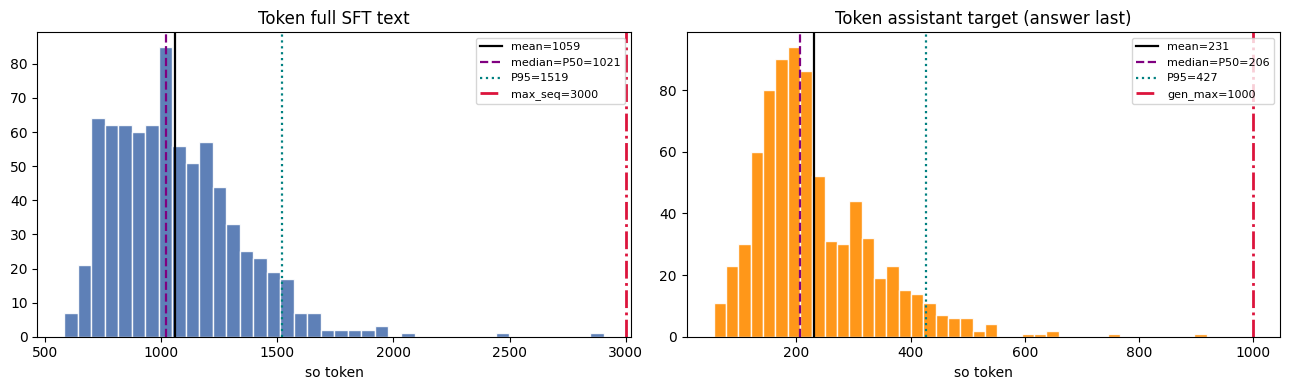

In [49]:
# === QA SFT token length (khop luc train) ===
import yaml
from transformers import AutoTokenizer
from models.QA_model.prepare_data import (
    SYSTEM_PROMPT_QA_COT, build_samples_from_split, load_qa_split,
)

_yaml = PROJECT_ROOT / "configs" / "qa_model.yaml"
_cfg = yaml.safe_load(_yaml.read_text(encoding="utf-8")) if _yaml.is_file() else {}
_mname = (_cfg.get("model") or {}).get("name", "Qwen/Qwen3.5-4B")
_max_seq = (_cfg.get("model") or {}).get("max_seq_length", 3500)
_gen_max = (_cfg.get("model") or {}).get("gen_max_new_tokens", 768)
print(f"Tokenizer: {_mname} | max_seq_length={_max_seq} | gen_max_new_tokens={_gen_max}")
tok = AutoTokenizer.from_pretrained(_mname, trust_remote_code=True)
print(f"SYSTEM_PROMPT_QA_COT tokens: {len(tok.encode(SYSTEM_PROMPT_QA_COT, add_special_tokens=False))}")

recs = []
for split in ("train", "dev", "test"):
    try:
        rws = load_qa_split(PROJECT_ROOT / "data", split)
    except FileNotFoundError:
        print(f"[skip] thieu data/processed/{split}.csv — chay cell Export train/dev/test CSV ben tren")
        continue
    samples, skipped = build_samples_from_split(rws)
    print(f"{split}: {len(samples)} mau (skip {skipped} thieu reasoning)")
    for s in samples:
        m = s["messages"]
        full = tok.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
        recs.append({
            "split": split,
            "n_full": len(tok.encode(full, add_special_tokens=False)),
            "n_user": len(tok.encode(m[1]["content"], add_special_tokens=False)),
            "n_asst": len(tok.encode(m[2]["content"], add_special_tokens=False)),
        })

dft = pd.DataFrame(recs)
if len(dft):
    for col, name in [("n_full", "full text"), ("n_asst", "assistant (answer LAST)"), ("n_user", "user msg")]:
        s = dft[col]
        print(f"\n[{name}] mean={s.mean():.0f} P50={s.quantile(.5):.0f} P95={s.quantile(.95):.0f} P99={s.quantile(.99):.0f} max={s.max()}")
    print(f"\n% assistant > gen_max_new_tokens({_gen_max}): {100*(dft['n_asst']>_gen_max).mean():.2f}%  (answer o cuoi -> cat = mat answer!)")
    print(f"% full > max_seq_length({_max_seq}): {100*(dft['n_full']>_max_seq).mean():.2f}%")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    _specs = [
        (ax[0], "n_full",  "#4C72B0",    "Token full SFT text",                 _max_seq, f"max_seq={_max_seq}"),
        (ax[1], "n_asst",  "darkorange", "Token assistant target (answer last)", _gen_max, f"gen_max={_gen_max}"),
    ]
    for a, col, color, title, ref, ref_label in _specs:
        s = dft[col]
        a.hist(s, bins=40, color=color, edgecolor="white", alpha=0.9)
        a.axvline(s.mean(),        color="black",   ls="-",  lw=1.6, label=f"mean={s.mean():.0f}")
        a.axvline(s.median(),      color="purple",  ls="--", lw=1.6, label=f"median=P50={s.median():.0f}")
        a.axvline(s.quantile(.95), color="teal",    ls=":",  lw=1.6, label=f"P95={s.quantile(.95):.0f}")
        a.axvline(ref,             color="crimson", ls="-.", lw=2.0, label=ref_label)
        a.set_title(title); a.set_xlabel("so token"); a.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / "F_qa_token.png", dpi=120); plt.show()
